In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [6]:
clean_df=pd.read_csv('clean_resume_data.csv')

In [7]:
clean_df.head()

,ID,Category,Feature
0,16852973,HR,hr administrator marketing associate hr admini...
1,22323967,HR,hr specialist hr operations summary media prof...
2,33176873,HR,hr director summary years experience recruitin...
3,27018550,HR,hr specialist summary dedicated driven dynamic...
4,17812897,HR,hr manager skill highlights hr skills hr depar...


In [8]:
clean_df.shape

(2484, 3)

In [9]:
clean_df['Category'].value_counts()


Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [10]:
from sklearn.utils import resample
max_count=clean_df['Category'].value_counts().max()

balaned_data=[]
for category in clean_df['Category'].unique():
    category_data=clean_df[clean_df['Category']==category]
    if len(category_data)<max_count:
        balanced_category_data=resample(category_data,replace=True,n_samples=max_count,random_state=42)
    else:
        balanced_category_data=resample(category_data,replace=False,n_samples=max_count,random_state=42)
    balaned_data.append(balanced_category_data)
balanced_df=pd.concat(balaned_data,axis=0)

In [11]:
balanced_df['Category'].value_counts()

Category
HR                        120
DESIGNER                  120
INFORMATION-TECHNOLOGY    120
TEACHER                   120
ADVOCATE                  120
BUSINESS-DEVELOPMENT      120
HEALTHCARE                120
FITNESS                   120
AGRICULTURE               120
BPO                       120
SALES                     120
CONSULTANT                120
DIGITAL-MEDIA             120
AUTOMOBILE                120
CHEF                      120
FINANCE                   120
APPAREL                   120
ENGINEERING               120
ACCOUNTANT                120
CONSTRUCTION              120
PUBLIC-RELATIONS          120
BANKING                   120
ARTS                      120
AVIATION                  120
Name: count, dtype: int64

In [12]:
balanced_df.isnull().sum()
balanced_df.dropna(inplace=True)

In [13]:
x=balanced_df['Feature']
y=balanced_df['Category']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
x_train

228     director information technology professional p...
1557    senior finance manager summary highly driven f...
1194    consultant summary media planner media buyer r...
916     adult education teacher accomplishments cal po...
2150    banking summary high energy manager successful...
                              ...                        
1328    director executive profile forward thinker exp...
973     bpo team leader summary seeking provide top qu...
979     manager administration facilities executive su...
1027    pmc psm sales manager sales associate career f...
793     fitness specialist summary energetic personal ...
Name: Feature, Length: 2303, dtype: str

In [15]:
tfidf_vectorizer=TfidfVectorizer()
x_train_tfidf=tfidf_vectorizer.fit_transform(x_train)
x_test_tfidf=tfidf_vectorizer.transform(x_test)

x_test_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 179711 stored elements and shape (576, 29780)>

In [16]:
# LinearSVC (replaced RandomForestClassifier for better accuracy)
rf_classifier=LinearSVC()
rf_classifier.fit(x_train_tfidf,y_train)

y_pred=rf_classifier.predict(x_test_tfidf)
accuracy=accuracy_score(y_test,y_pred)
print('Accuracy:',accuracy)

Accuracy: 0.8732638888888888


In [17]:
print(classification_report(y_test,y_pred))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.95      0.95      0.95        21
              ADVOCATE       0.96      0.83      0.89        29
           AGRICULTURE       0.86      0.83      0.84        23
               APPAREL       0.95      0.86      0.90        21
                  ARTS       0.89      0.77      0.83        22
            AUTOMOBILE       0.95      1.00      0.97        19
              AVIATION       0.88      0.97      0.92        30
               BANKING       0.95      0.78      0.86        23
                   BPO       0.94      1.00      0.97        15
  BUSINESS-DEVELOPMENT       0.57      0.67      0.62        18
                  CHEF       0.96      0.96      0.96        28
          CONSTRUCTION       0.89      1.00      0.94        25
            CONSULTANT       1.00      0.71      0.83        31
              DESIGNER       0.96      0.93      0.95        28
         DIGITAL-MEDIA       0.86      

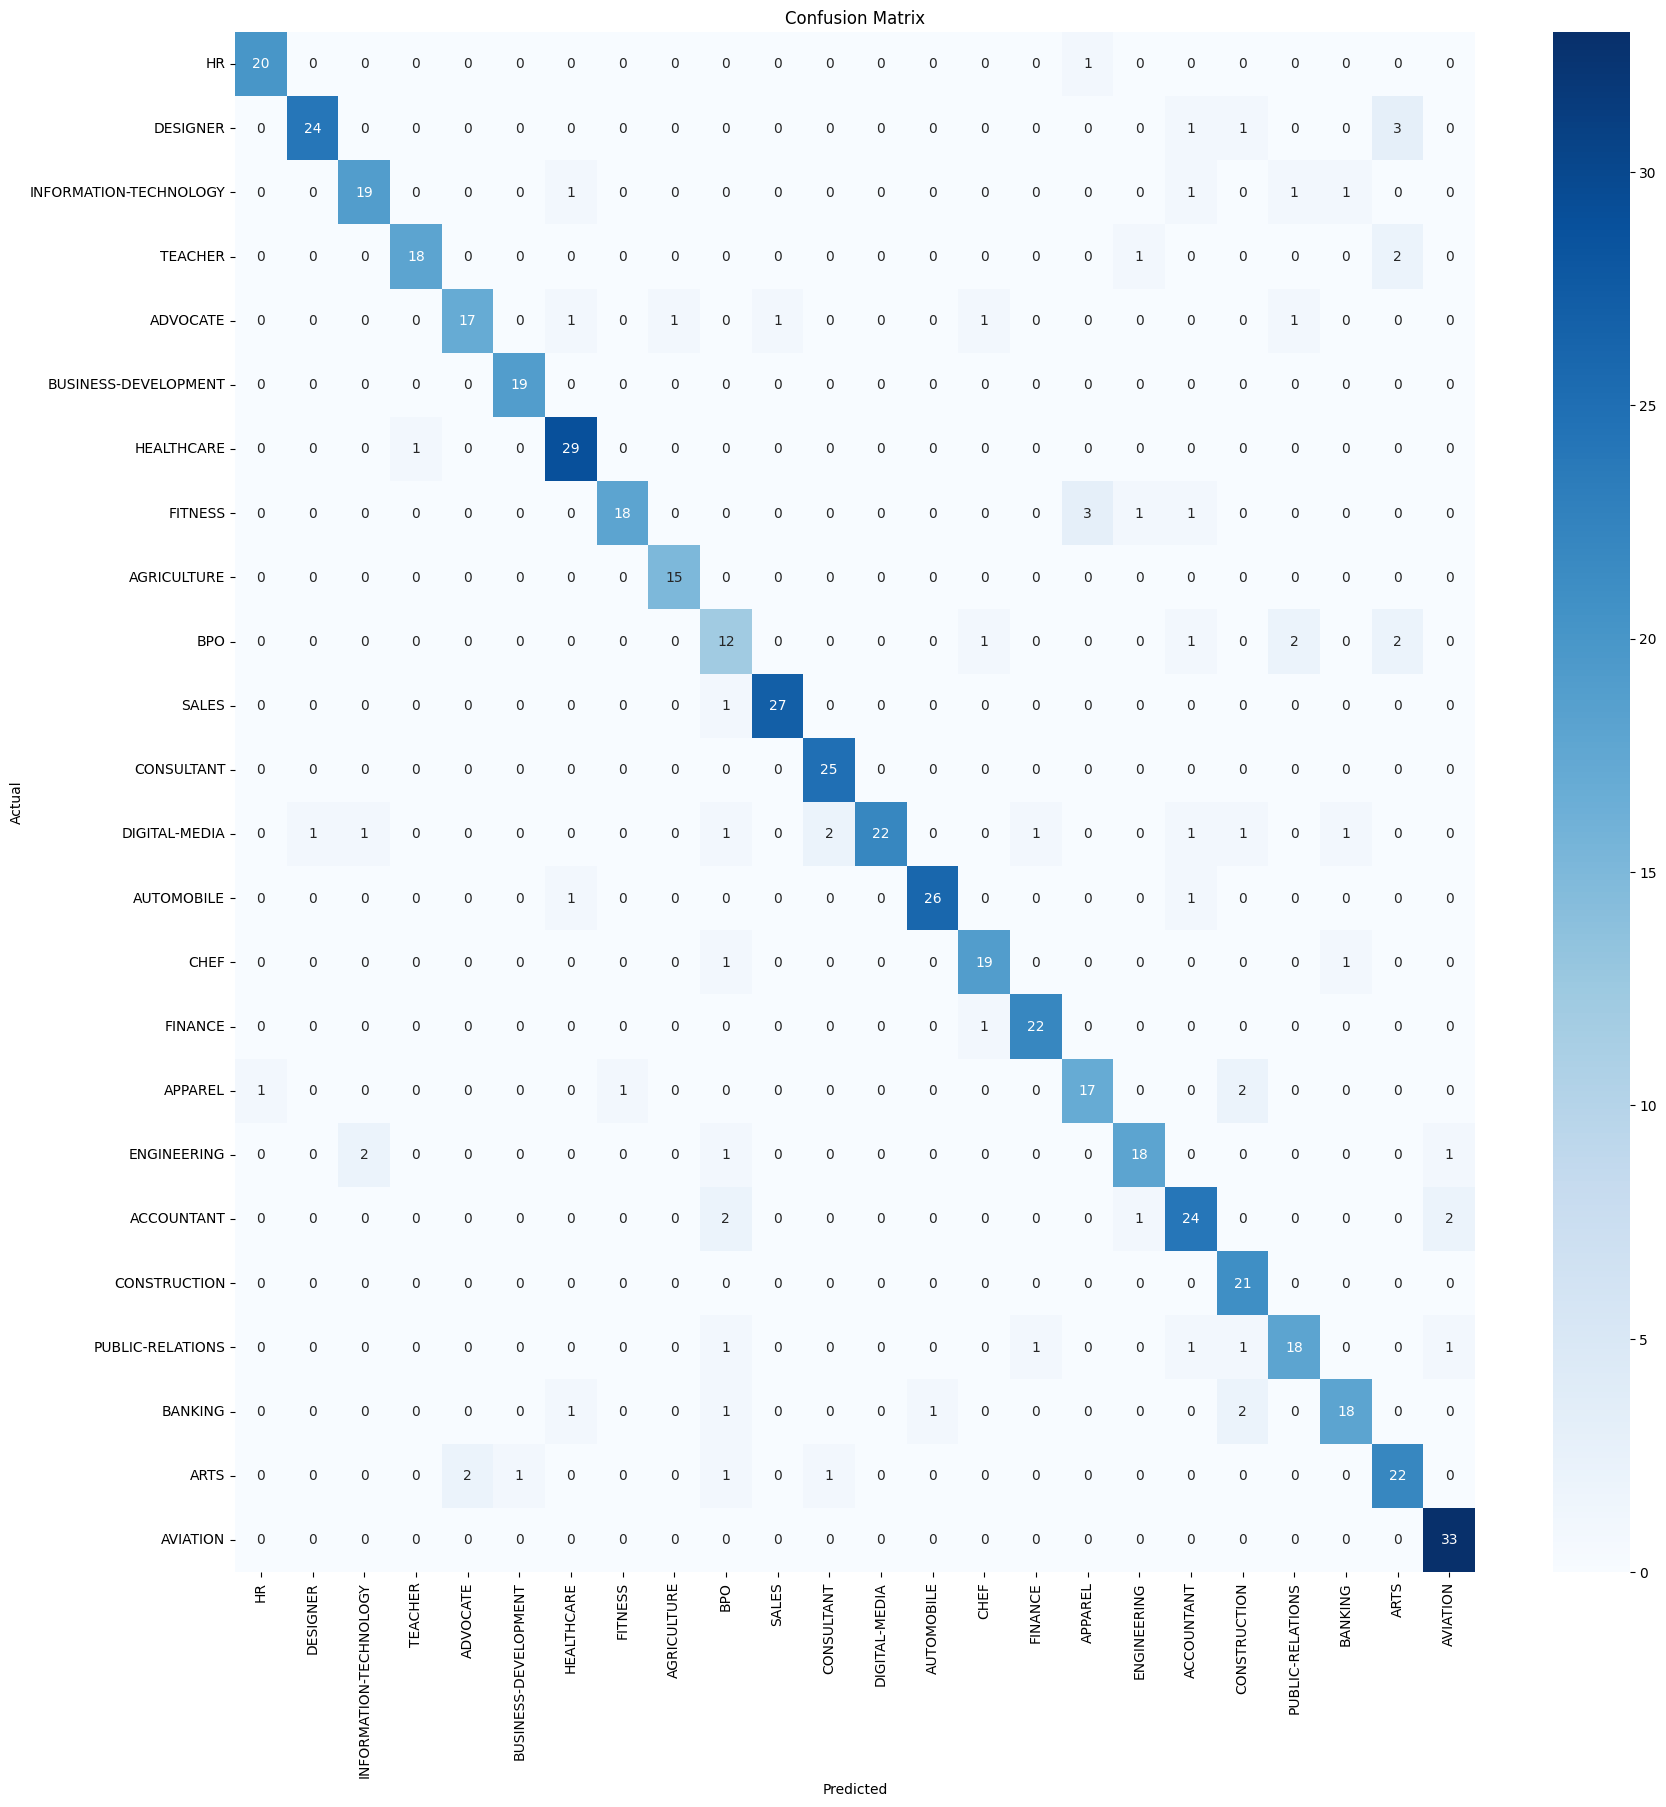

In [18]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(20,20))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=balanced_df['Category'].unique(),yticklabels=balanced_df['Category'].unique())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [19]:
import pickle
pickle.dump(rf_classifier,open('models/rf_classifier.pkl',"wb"))
pickle.dump(tfidf_vectorizer,open('models/tfidf_vectorizer.pkl',"wb"))